In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('/content/Global_Superstore2 - Global_Superstore2.csv')

#**Data Types & Structure**

In [ ]:
df.shape

(51290, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17741 entries, 0 to 17740
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          17741 non-null  int64  
 1   Order ID        17741 non-null  object 
 2   Order Date      17741 non-null  object 
 3   Ship Date       17741 non-null  object 
 4   Ship Mode       17741 non-null  object 
 5   Customer ID     17741 non-null  object 
 6   Customer Name   17741 non-null  object 
 7   Segment         17741 non-null  object 
 8   City            17741 non-null  object 
 9   State           17741 non-null  object 
 10  Country         17740 non-null  object 
 11  Postal Code     2918 non-null   float64
 12  Market          17740 non-null  object 
 13  Region          17740 non-null  object 
 14  Product ID      17740 non-null  object 
 15  Category        17740 non-null  object 
 16  Sub-Category    17740 non-null  object 
 17  Product Name    17740 non-null 

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [ ]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,29002,IN-2014-62366,19-06-2014,19-06-2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20-06-2014,24-06-2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,02-12-2013,02-12-2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18-02-2012,22-02-2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium
51289,6147,MX-2012-134460,22-05-2012,26-05-2012,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,...,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.380,3,0.0,1.8000,0.00,High


In [ ]:
df_copy = df.copy()

## **Handling Missing Values**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [ ]:
# Display the full row where 'Market' is null
df[df['Market'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
17740,7445,MX-2014-138569,26-12-2014,27-12-2014,First Class,KH-16360,Katherine Hughes,Consumer,Tuxtla Gutiérrez,Chi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#**Data cleaning**
---

In [ ]:
# Remove rows where 'Market' is missing in-place
df.dropna(subset=['Market'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


Handle Missing Values

In [ ]:
# Impute missing Postal Code using the mode (most common value) for each City
df['Postal Code'] = df.groupby('City')['Postal Code'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)
# Optional: Fill any remaining missing values (cities without any postal code in the dataset) with a placeholder or 'Unknown'
df['Postal Code'] = df['Postal Code'].fillna('Unknown')


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
City,object
State,object


### Convert Order Date and Ship Date to datetime

In [5]:

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

# Verify the data types
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


##Remove Duplicate

In [8]:
# Check count of duplicate rows
print("Duplicate rows count:", df.duplicated().sum())

Duplicate rows count: 0


#**Feature Engineering**
---

###Add Delivery Duration Column

In [ ]:
# Create the new column calculating delivery time in days
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days



,Order Date,Ship Date,Delivery Time
0,2012-07-31,2012-07-31,0
1,2013-02-05,2013-02-07,2
2,2013-10-17,2013-10-18,1
3,2013-01-28,2013-01-30,2
4,2013-11-05,2013-11-06,1


###Extract Order Year

In [6]:
# Extract year from Order Date
df['Order_Year'] = df['Order Date'].dt.year

###Extract Order Month

In [7]:
# Extract full month name
df['Order_Month'] = df['Order Date'].dt.month_name()

In [ ]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost,Delivery Time
count,17740.000000,17740,17740,17740.000000,17740.000000,17740.000000,17740.000000,17740.000000,17740.000000
mean,23983.007723,2013-05-13 16:26:14.746336,2013-05-17 08:32:26.516347136,586.408810,4.361781,0.111738,73.449403,66.911276,3.670970
min,8.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,31.680000,1.000000,0.000000,-6599.978000,15.320000,0.000000
25%,12720.500000,2012-06-22 00:00:00,2012-06-26 00:00:00,211.298250,2.000000,0.000000,5.825340,23.260000,2.000000
50%,23205.500000,2013-07-10 00:00:00,2013-07-13 00:00:00,366.855000,4.000000,0.000000,48.892500,37.865000,4.000000
75%,34756.500000,2014-05-21 00:00:00,2014-05-25 00:00:00,695.826000,6.000000,0.200000,126.324000,73.630000,5.000000
max,51289.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.976000,933.570000,7.000000
std,13890.735502,NaN,NaN,701.455309,2.511758,0.170189,285.677919,83.364662,1.797588


#**Exploratory Data Analysis (EDA)**

In [ ]:
all = ['Sales','Quantity', 'Discount', 'Profit','Shipping Cost']

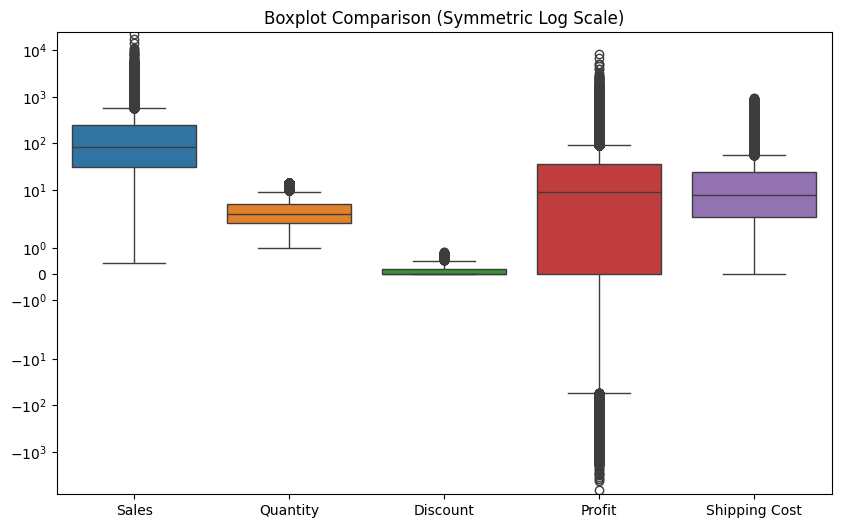

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[all])
plt.yscale('symlog')  # Handles negative values in Profit while scaling large values
plt.title('Boxplot Comparison (Symmetric Log Scale)')
plt.xticks
plt.show()

In [ ]:
# Calculate IQR and outlier bounds
Q1 = df[all].quantile(0.25)
Q3 = df[all].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Print IQR values
print("IQR:\n", IQR)

IQR:
 Sales            220.294575
Quantity           3.000000
Discount           0.200000
Profit            36.810000
Shipping Cost     21.840000
dtype: float64


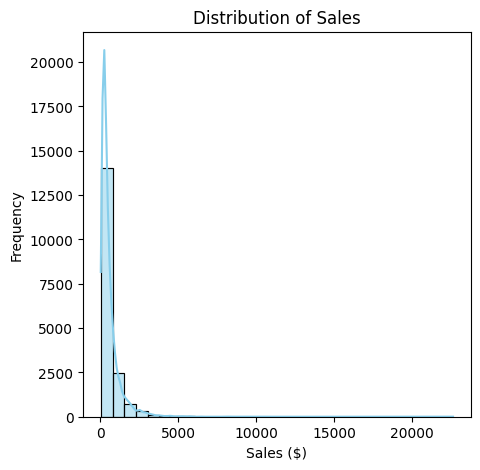

In [ ]:
plt.figure(figsize=(5, 5))
sns.histplot(df['Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

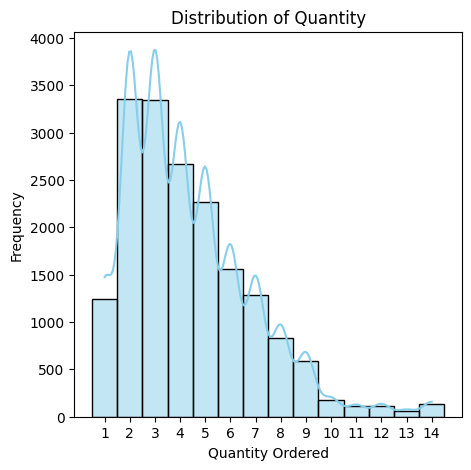

In [ ]:
plt.figure(figsize=(5, 5))
sns.histplot(df['Quantity'], discrete=True, color='skyblue',kde=True, edgecolor='black')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity Ordered')
plt.ylabel('Frequency')
plt.xticks(range(int(df['Quantity'].min()), int(df['Quantity'].max()) + 1))
plt.show()

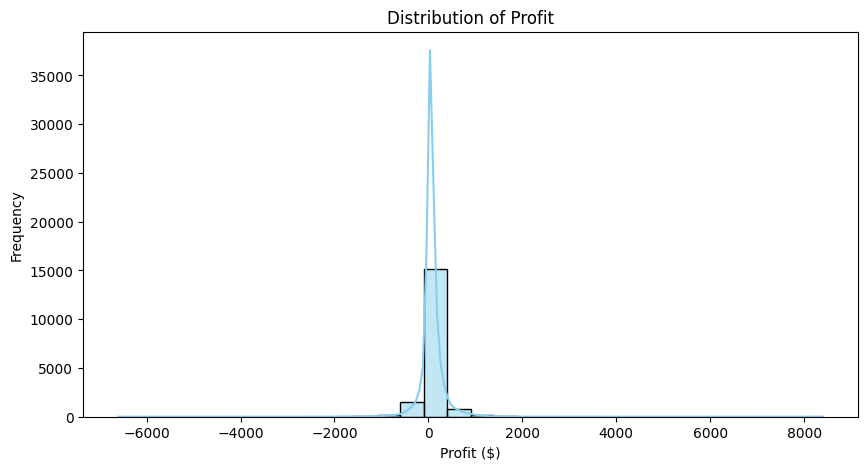

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Profit'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Profit')
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.show()

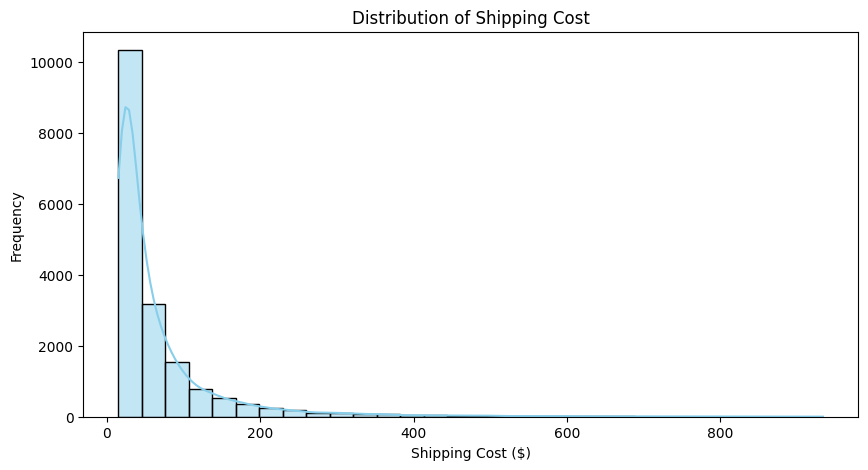

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Shipping Cost'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Shipping Cost')
plt.xlabel('Shipping Cost ($)')
plt.ylabel('Frequency')
plt.show()

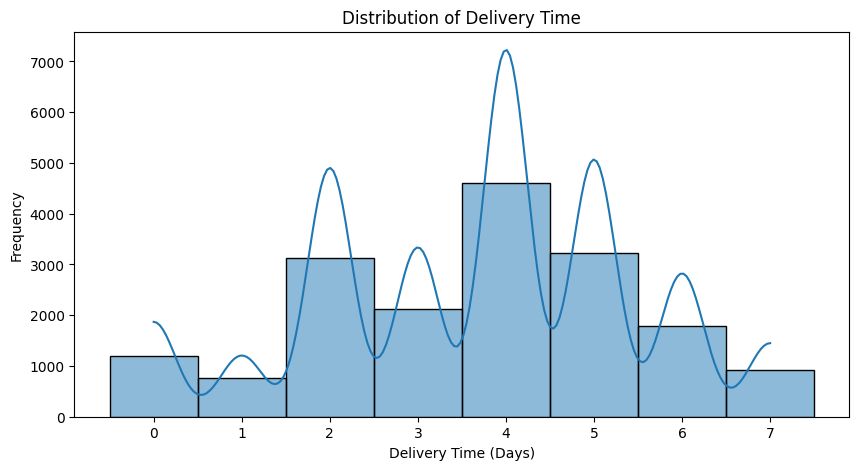

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Delivery Time'], discrete=True, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')
plt.xticks(range(int(df['Delivery Time'].min()), int(df['Delivery Time'].max()) + 1))
plt.show()

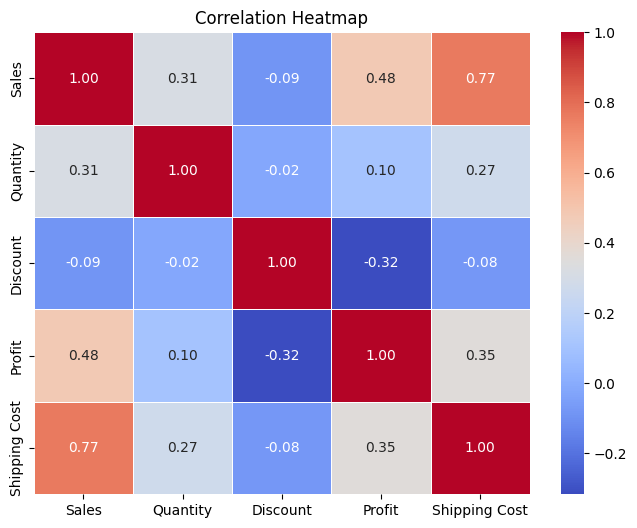

In [ ]:
# Compute correlation matrix for numerical columns
corr = df[all].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Create a 'Year' column from 'Order Date'
df['Order_Year'] = df['Order Date'].dt.year

# Calculate yearly sales
yearly_sales = df.groupby('Order_Year')['Sales'].sum().reset_index()

# Display the results formatted as currency
yearly_sales['Sales'] = yearly_sales['Sales'].map('${:,.2f}'.format)
print(yearly_sales)

   Order_Year          Sales
0        2011  $2,259,450.90
1        2012  $2,677,438.69
2        2013  $3,405,746.45
3        2014  $4,299,865.87


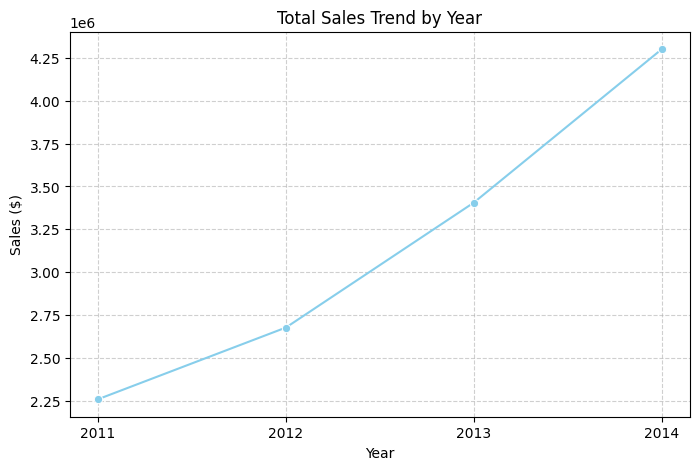

In [ ]:
# Group numeric sales values by year
yearly_sales_numeric = df.groupby('Order_Year')['Sales'].sum().reset_index()

# Plot line chart
plt.figure(figsize=(8, 5))
sns.lineplot(data=yearly_sales_numeric, x='Order_Year', y='Sales', marker='o', color='skyblue')

plt.title('Total Sales Trend by Year')
plt.xlabel('Year')
plt.ylabel('Sales ($)')
plt.xticks(yearly_sales_numeric['Order_Year'])  # Show distinct year ticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Calculate total sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

# Sort by Sales descending for better presentation
region_sales = region_sales.sort_values(by='Sales', ascending=False)

# Display formatted values
region_sales_display = region_sales.copy()
region_sales_display['Sales'] = region_sales_display['Sales'].map('${:,.2f}'.format)
print(region_sales_display)

            Region          Sales
3          Central  $2,822,302.52
10           South  $1,600,907.04
7            North  $1,248,165.60
9          Oceania  $1,100,184.61
11  Southeast Asia    $884,423.17
8       North Asia    $848,309.78
5             EMEA    $806,161.31
0           Africa    $783,773.21
4     Central Asia    $752,826.57
12            West    $725,457.82
6             East    $678,781.24
2        Caribbean    $324,280.86
1           Canada     $66,928.17


/tmp/ipykernel_1169/3285857517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_r')


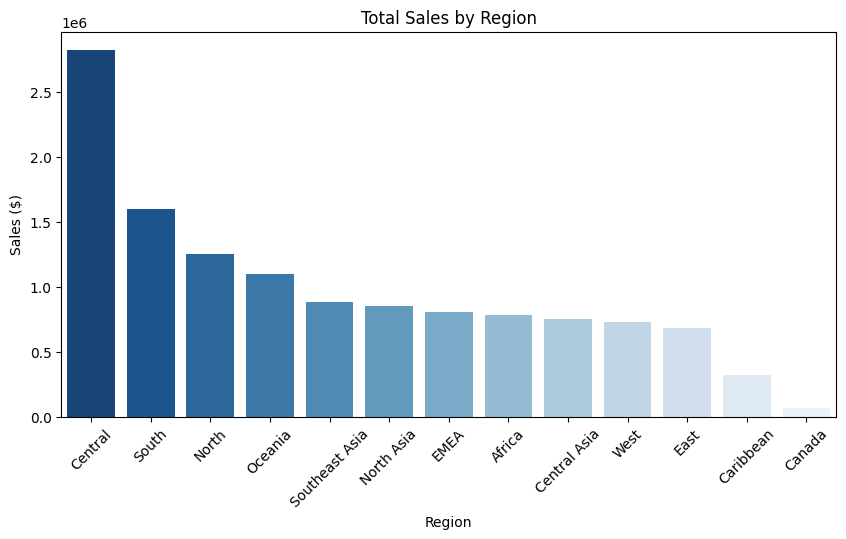

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_r')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()

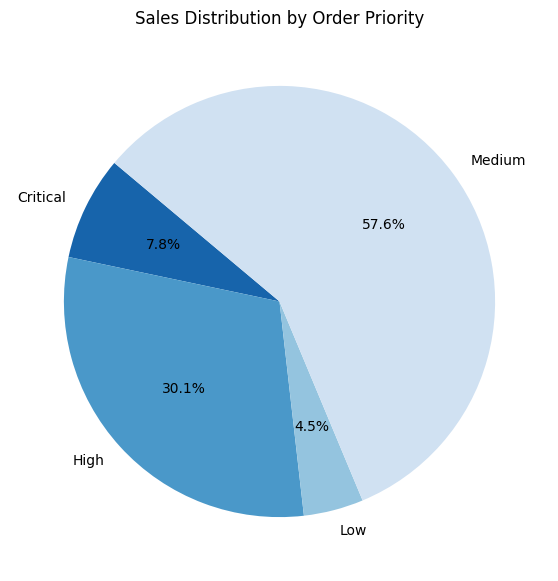

In [ ]:
# Aggregate sales by Order Priority
priority_sales = df.groupby('Order Priority')['Sales'].sum()

# Plot Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(
    priority_sales,
    labels=priority_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Blues_r', len(priority_sales))
)

plt.title('Sales Distribution by Order Priority')
plt.show()

/tmp/ipykernel_1169/1008517186.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_r')


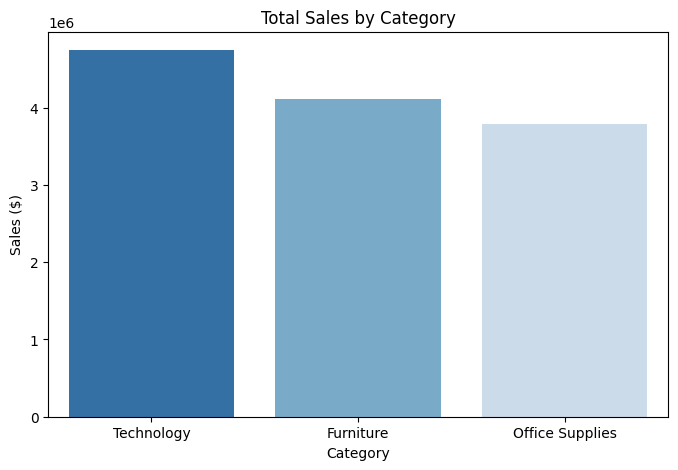

In [ ]:
# Aggregate sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales', ascending=False)

# Bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_r')
plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')
plt.show()

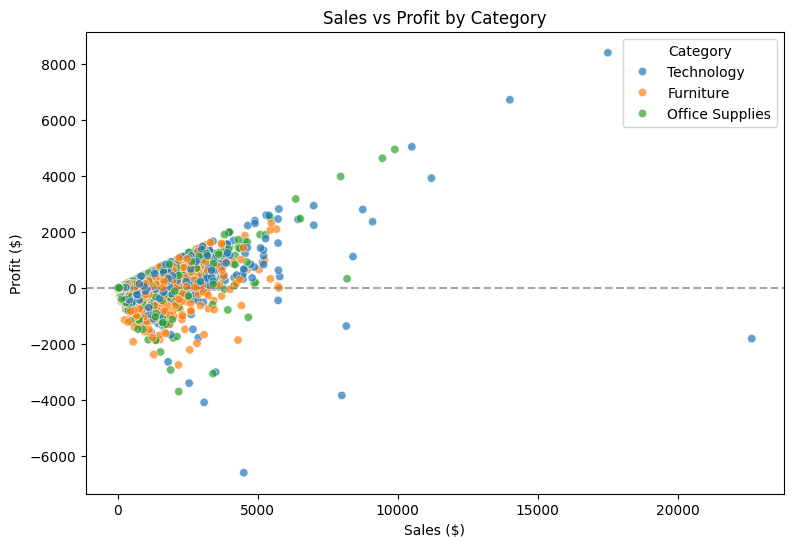

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.7)

plt.title('Sales vs Profit by Category')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.7)  # Line at 0 profit
plt.show()

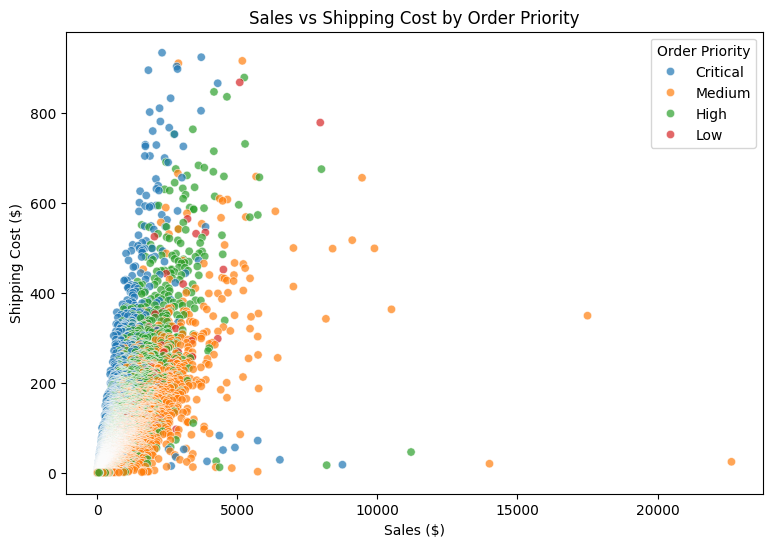

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Sales', y='Shipping Cost', hue='Order Priority', alpha=0.7)

plt.title('Sales vs Shipping Cost by Order Priority')
plt.xlabel('Sales ($)')
plt.ylabel('Shipping Cost ($)')
plt.show()

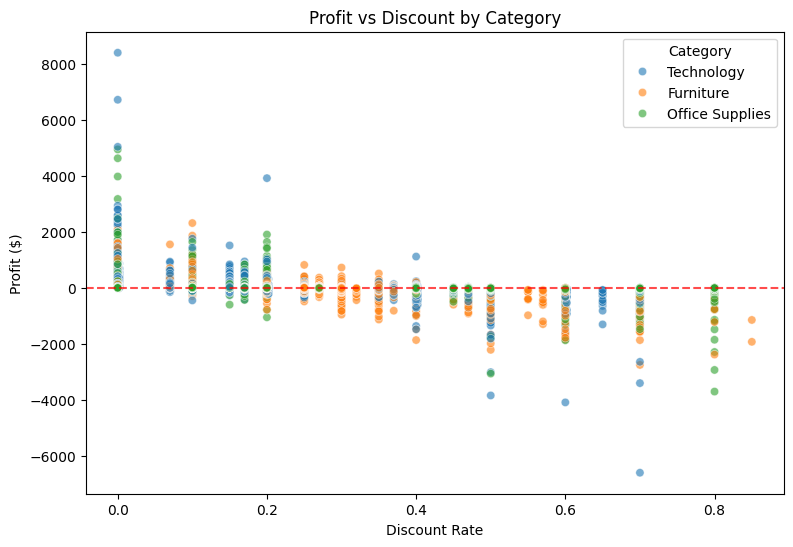

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)

plt.title('Profit vs Discount by Category')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)  # Red line at 0 profit (loss threshold)
plt.show()

In [ ]:
# Count unique orders by Ship Mode
ship_mode_counts = df.groupby('Ship Mode')['Order ID'].nunique().reset_index()
ship_mode_counts = ship_mode_counts.rename(columns={'Order ID': 'Order_Count'})
ship_mode_counts = ship_mode_counts.sort_values(by='Order_Count', ascending=False)

print(ship_mode_counts)

        Ship Mode  Order_Count
3  Standard Class        15154
2    Second Class         5119
0     First Class         3821
1        Same Day         1347


/tmp/ipykernel_1169/171850147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ship_mode_counts, x='Ship Mode', y='Order_Count', palette='Blues_r')


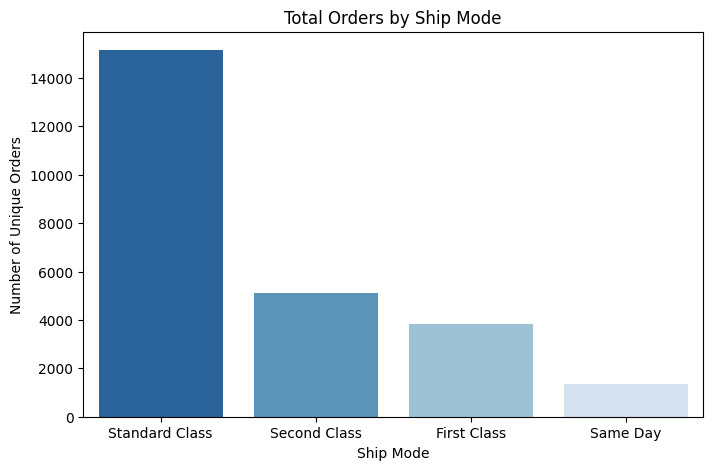

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=ship_mode_counts, x='Ship Mode', y='Order_Count', palette='Blues_r')

plt.title('Total Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Unique Orders')
plt.show()